# 均值回归策略向量化回测：GDX / GLD 示例

动量策略假设收益率之间存在正相关，涨的会继续涨. 均值回归策略正好相反，假设收益率之间存在负相关：一个标的相对其自身趋势涨得太多，就该做空；跌得太多，就该做多。这里用简单移动平均线 SMA 作为趋势路径的代理，当价格偏离 SMA 超过一定阈值时，就认为出现了均值回归的交易信号。

本 notebook 用两个和黄金相关的标的做演示，因为它们通常表现出比较明显的均值回归特征. GDX 是 VanEck 黄金矿业股 ETF，跟踪 NYSE Arca 黄金矿业指数，通过投资金矿公司股票间接跟踪金价；GLD 是 SPDR 黄金 ETF，全球规模最大的实物黄金 ETF，直接持有实物黄金。

本 notebook 先在 GDX 上做信号探索，把价格与 SMA 的偏离度、生成的仓位、策略净值曲线都画出来看一遍；再把这套逻辑封装成通用的回测类；最后用这个类在 GLD 上跑一次带交易成本的完整回测。

因为我访问不到作者本地准备好的数据文件，本 notebook 里的 get_price_data 会优先尝试用 yfinance 从 Yahoo Finance 下载真实历史价格，下载不了的话，就自动换成一段模拟生成的价格序列，保证代码本身能跑通。如果你手头有更稳定的数据源，比如 akshare、tushare 之类，可以替换掉 yfinance, 因为 yfinance 在大陆不稳定。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

try:
    import yfinance as yf
    HAS_YFINANCE = True
except ImportError:
    HAS_YFINANCE = False
    print("未检测到 yfinance，可运行 `pip install yfinance` 后重启内核以启用真实数据下载。")
    print("目前将自动使用模拟数据继续运行。")


## 1. 数据获取函数：

In [2]:
def get_price_data(symbol, start="2010-01-01", end="2019-12-31", seed=42):
    """
    获取某个标的的收盘价序列，返回一个只有 'price' 列的 DataFrame。

    优先尝试通过 yfinance 从 Yahoo Finance 下载真实数据；
    如果网络不可用，则退化为一段带轻微均值回归成分的几何布朗运动模拟价格，以保证 notebook 在任何环境下都能跑通。
    读者不必纠结几何布朗运动的算法，不是本节的重点，只要知道他能生成比较符合现实的模拟价格信号即可。
    """
    if HAS_YFINANCE:
        try:
            df = yf.download(symbol, start=start, end=end, progress=False)
            if df is not None and len(df) > 0:
                price = df["Close"].dropna().squeeze()
                price.name = "price"
                print(f"[{symbol}] 已从 Yahoo Finance 下载 {len(price)} 条真实收盘价数据")
                return price.to_frame()
        except Exception as e:
            print(f"[{symbol}] 下载失败（{e}），改用模拟数据")

    # ---- 模拟数据兜底 ----
    rng = np.random.default_rng(seed if symbol == "GDX" else seed + 1)
    dates = pd.bdate_range(start=start, end=end)
    n = len(dates)
    mu, sigma = 0.00015, 0.012
    rets = rng.normal(mu, sigma, n)
    # 叠加一个缓慢震荡的趋势项，让价格围绕趋势线波动，
    # 这样均值回归策略在模拟数据上也能产生有意义的信号
    trend = np.sin(np.linspace(0, 15, n)) * 0.15
    log_price = np.cumsum(rets) + trend
    price = 100 * np.exp(log_price - log_price[0])
    print(f"[{symbol}] 未获取到真实数据，使用模拟价格序列（{n} 条），仅用于演示回测流程")
    return pd.DataFrame({"price": price}, index=dates)


## 2. GDX 均值回归信号探索：

SMA = 25，threshold = 3.5

先算出 GDX 每日的对数收益率，再算 25 日 SMA 作为趋势路径，然后用当前价格减去 SMA 得到偏离度 distance。distance 越大说明价格离趋势线越远，均值回归的力量也就越大。阈值设为 3.5，超过这个幅度就认为出现了交易信号。

In [10]:
import os
proxy = 'http://127.0.0.1:7897' # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

[GDX] 已从 Yahoo Finance 下载 2515 条真实收盘价数据


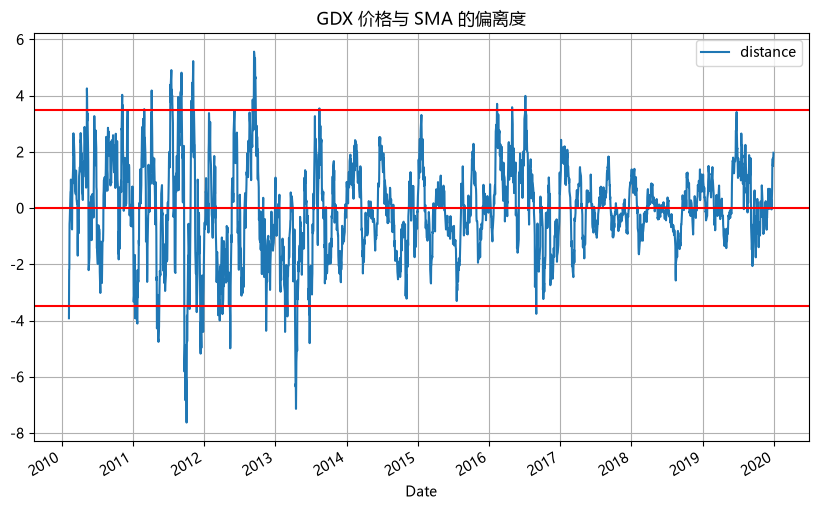

In [4]:
raw_gdx = get_price_data("GDX", "2010-01-01", "2019-12-31")

data = raw_gdx.copy()
data["returns"] = np.log(data["price"] / data["price"].shift(1))

SMA = 25
data["SMA"] = data["price"].rolling(SMA).mean()

threshold = 3.5
data["distance"] = data["price"] - data["SMA"]

data["distance"].dropna().plot(title="GDX 价格与 SMA 的偏离度", legend=True)
plt.axhline(threshold, color="r")
plt.axhline(-threshold, color="r")
plt.axhline(0, color="r")
plt.show()


根据 distance 和阈值生成仓位：偏离度大于阈值，说明涨得太多，做空；偏离度小于负阈值，说明跌得太多，做多；如果 distance 的符号发生了变化，说明价格已经穿过 SMA、回归到趋势线附近，这时候平仓，仓位归零；其余情况保持前一天的仓位不变。用 ffill 把中间没有触发信号的日子都填成上一次的仓位。

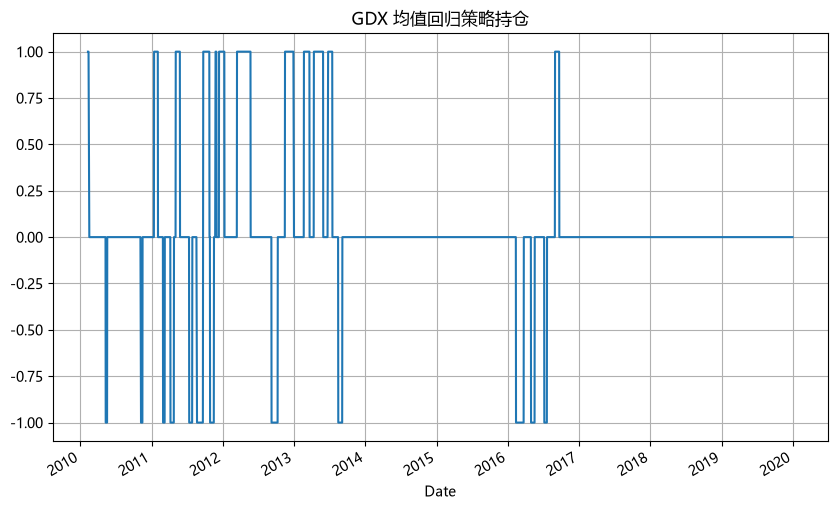

In [5]:
def mean_reversion_positions(distance, threshold):
    pos = np.select(
        [distance > threshold, distance < -threshold],
        [-1, 1],
        default=np.nan,
    )
    pos = np.where(distance * distance.shift(1) < 0, 0, pos)
    return pd.Series(pos, index=distance.index).ffill().fillna(0)

data["position"] = mean_reversion_positions(data["distance"], threshold)
data["position"].iloc[SMA:].plot(ylim=[-1.1, 1.1], title="GDX 均值回归策略持仓")
plt.show()

把仓位和第二天的收益率相乘，就得到策略每天的收益。这里用 shift(1) 是为了避免用到未来信息：今天算出的仓位，只能作用在明天的收益上。
把策略收益和原始收益率都做累计求和再取指数，就能画出净值曲线，直接对比策略和直接持有标的的表现差异。

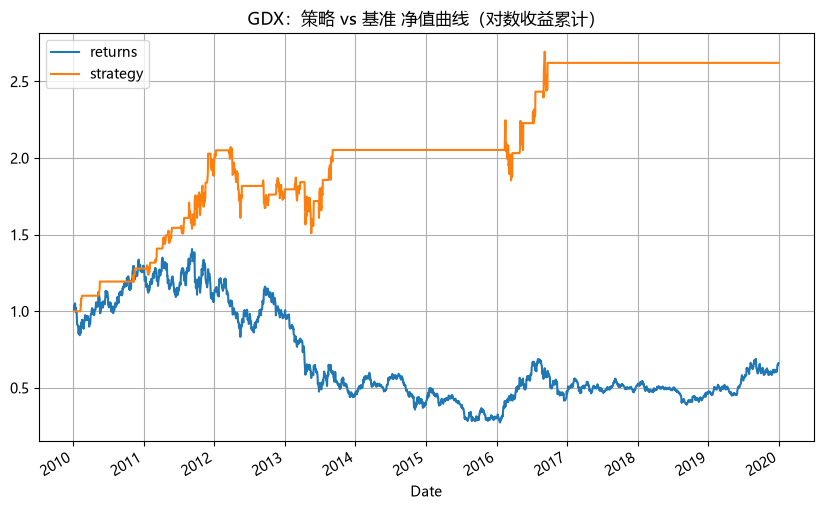

In [6]:
data["strategy"] = data["position"].shift(1) * data["returns"]

data[["returns", "strategy"]].dropna().cumsum().apply(np.exp).plot(
    title="GDX：策略 vs 基准 净值曲线（对数收益累计）"
)
plt.show()

## 3. 通用向量化回测类：MomVectorBacktester 和 MRVectorBacktester

上面的探索性代码只能针对一个标的，改起来比较麻烦。这里把整个流程封装成类，方便后续更换标的、更换参数、更换交易成本。

MomVectorBacktester 是一个基础的动量策略回测类，负责下载数据、算收益率、按动量方向开仓、算净值曲线，并且在每次换仓时扣一笔交易成本。MRVectorBacktester 继承自它，只重写 run_strategy 这一个方法，把动量逻辑换成前面演示过的均值回归逻辑，其余取数据、算净值、画图的部分都直接复用父类。

In [7]:
class MomVectorBacktester:
    """基于动量策略的向量化回测基类"""

    def __init__(self, symbol, start, end, amount, tc):
        self.symbol = symbol      # 标的代码，如 "GLD"、"GDX"
        self.start = start        # 回测起始日期，如 "2010-1-1"
        self.end = end            # 回测结束日期，如 "2019-12-31"
        self.amount = amount      # 初始资金（本金），用于把收益率换算成绝对金额
        self.tc = tc              # 单次交易成本（固定金额），每次换仓时从策略净值中扣除
        self.results = None       # 回测结果 DataFrame，run_strategy() 执行后才有值
        self.get_data()           # 初始化时立即拉取价格数据并计算对数收益率

    def get_data(self):
        raw = get_price_data(self.symbol, self.start, self.end)
        raw["return"] = np.log(raw["price"] / raw["price"].shift(1))
        self.data = raw

    def run_strategy(self, momentum=1):
        # 1. 复制数据并去掉缺失值，避免 rolling 计算受 NaN 干扰
        data = self.data.copy().dropna()

        # 2. 计算仓位：过去 momentum 天平均收益为正 → 做多(+1)，为负 → 做空(-1)
        #    动量策略每天都重新定仓，不需要 ffill
        data["position"] = np.sign(data["return"].rolling(momentum).mean())

        # 3. 计算策略日收益：用 shift(1) 把仓位滞后一天，避免用到未来信息
        #    今天决定的仓位，只能作用在明天的收益上
        data["strategy"] = data["position"].shift(1) * data["return"]

        # 4. 去掉 rolling / shift 产生的 NaN 行，保证后续计算有效
        data.dropna(inplace=True)

        # 5. 计算基准（买入持有）和策略的累计净值曲线
        data["creturns"] = self.amount * data["return"].cumsum().apply(np.exp)
        data["cstrategy"] = self.amount * data["strategy"].cumsum().apply(np.exp)

        # 6. 识别发生交易的日期：仓位相对前一天发生变化
        trades = data["position"].diff().fillna(0) != 0

        # 7. 在交易发生的日期，从策略累计净值中扣除交易成本
        data.loc[trades, "cstrategy"] -= self.tc

        # 8. 保存结果，计算期末绝对收益和相对基准的超额收益
        self.results = data
        aperf = data["cstrategy"].iloc[-1]              # absolute performance：策略期末净值
        operf = aperf - data["creturns"].iloc[-1]       # out-/underperformance：相对买入持有的超额/落后
        return round(aperf, 2), round(operf, 2)

    def plot_results(self):
        if self.results is None:
            print("请先运行 run_strategy()")
            return
        title = f"{self.symbol} | 初始资金 {self.amount} | 交易成本 {self.tc}"
        self.results[["creturns", "cstrategy"]].plot(title=title)
        plt.show()


class MRVectorBacktester(MomVectorBacktester):
    """基于均值回归策略的向量化回测类，继承自 MomVectorBacktester"""

    def run_strategy(self, SMA, threshold):
        # 1. 复制原始数据（此处先保留 NaN，等 rolling 算完再统一 dropna）
        data = self.data.copy()

        # 2. 计算 SMA 作为趋势/均值路径的代理
        data["sma"] = data["price"].rolling(SMA).mean()

        # 3. 计算价格偏离度：正值 = 价格在 SMA 上方，负值 = 在下方
        data["distance"] = data["price"] - data["sma"]

        # 4. 去掉 SMA 尚未算出的前期 NaN 行
        data.dropna(inplace=True)

        # 5. 根据偏离度生成仓位（入场/出场/持有逻辑封装在 mean_reversion_positions 中）：
        #    - distance > threshold  → 做空(-1)
        #    - distance < -threshold → 做多(+1)
        #    - 穿越 SMA（distance 变号）→ 平仓(0)
        #    - 其余日子 ffill 维持上一次仓位
        data["position"] = mean_reversion_positions(data["distance"], threshold)

        # 6. 计算策略日收益：仓位滞后一天，避免未来函数
        data["strategy"] = data["position"].shift(1) * data["return"]

        # 7. 去掉 shift 产生的 NaN 行
        data.dropna(inplace=True)

        # 8. 计算基准和策略的累计净值曲线
        data["creturns"] = self.amount * data["return"].cumsum().apply(np.exp)
        data["cstrategy"] = self.amount * data["strategy"].cumsum().apply(np.exp)

        # 9. 识别交易日期，扣除交易成本
        trades = data["position"].diff().fillna(0) != 0
        data.loc[trades, "cstrategy"] -= self.tc

        # 10. 保存结果，返回期末绝对收益和超额收益
        self.results = data
        aperf = data["cstrategy"].iloc[-1]              # absolute performance：策略期末净值
        operf = aperf - data["creturns"].iloc[-1]       # out-/underperformance：相对买入持有的超额/落后
        return round(aperf, 2), round(operf, 2)


## 4. 在 GLD 上跑完整回测

SMA = 43，threshold = 7.5，交易成本 0.1%，初始资金 10000 美元

换到 GLD 上，参数也换成更宽的 SMA 43 天、阈值 7.5，并且这次加上了每次换仓 0.1% 的交易成本，更接近真实交易的情况。

`run_strategy` 返回 `aperf`（策略期末净值）和 `operf`（相对买入持有的超额/落后）。

[GLD] 已从 Yahoo Finance 下载 2515 条真实收盘价数据
aperf（策略期末净值）: 14207.84
operf（相对买入持有的超额/落后）: 1336.26

结果解读：
  回测区间 2010-01-01 至 2019-12-31，初始资金 10000 美元
  买入持有 GLD 期末约 12871.58 美元，累计收益约 28.7%
  均值回归策略期末 14207.84 美元，累计收益约 42.1%
  operf = 1336.26 > 0，说明在已扣每次换仓 0.1% 交易成本后，策略仍跑赢单纯持有 GLD
  超额部分约占初始资金的 13.4%


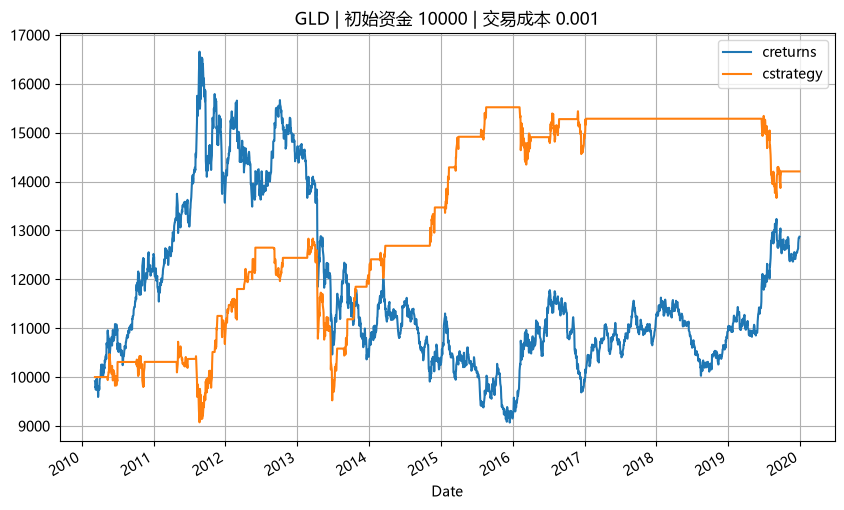

In [12]:
mrbt = MRVectorBacktester(symbol="GLD", start="2010-1-1", end="2019-12-31", amount=10000, tc=0.001)
aperf, operf = mrbt.run_strategy(SMA=43, threshold=7.5)

buy_hold = aperf - operf          # 买入持有 GLD 的期末净值
init = mrbt.amount
strat_ret = (aperf / init - 1) * 100
bh_ret = (buy_hold / init - 1) * 100

print(f"aperf（策略期末净值）: {aperf}")
print(f"operf（相对买入持有的超额/落后）: {operf}")
print()
print("结果解读：")
print(f"  回测区间 2010-01-01 至 2019-12-31，初始资金 {init} 美元")
print(f"  买入持有 GLD 期末约 {buy_hold:.2f} 美元，累计收益约 {bh_ret:.1f}%")
print(f"  均值回归策略期末 {aperf:.2f} 美元，累计收益约 {strat_ret:.1f}%")
if operf > 0:
    print(f"  operf = {operf:.2f} > 0，说明在已扣每次换仓 0.1% 交易成本后，策略仍跑赢单纯持有 GLD")
else:
    print(f"  operf = {operf:.2f} < 0，说明策略跑输单纯持有 GLD")
print(f"  超额部分约占初始资金的 {operf / init * 100:.1f}%")  

mrbt.plot_results()

## 5. 如何接入其他数据源

如果想用本地 CSV，把 get_price_data 里的下载逻辑换成 pd.read_csv，读进来之后保证列名是 price 就行，其余代码不用动。

如果 Yahoo Finance 访问不稳定，可以装 akshare 或 tushare 这类国内数据源，用对应的接口把 ETF 或个股的历史价格取下来，同样只需要整理成一个只有 price 列的 DataFrame 返回即可。

不管换成哪种数据源，只要接口返回格式统一成 price 这一列，GDX 探索部分和 MRVectorBacktester 回测部分的代码逻辑都完全不用改。
